# Vision Transformer Frequency Analysis
## Replicating 'What do Deep Networks Like to See?' using FFT

**Approach:** Input Image → FFT → Learnable Frequency Mask → IFFT → Frozen Classifier

---

## Section 1: Setup & Environment Check

### 1.1 GPU Check

In [4]:
# Check GPU availability
!nvidia-smi

Fri Nov 14 08:12:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1.2 Install Dependencies

In [5]:
# Install required packages
!pip install torch torchvision timm matplotlib numpy pillow -q

### 1.3 Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import os
import sys
from tqdm import tqdm

print("All libraries imported successfully!")

All libraries imported successfully!


### 1.4 Verify PyTorch GPU Access

In [2]:
# Check CUDA availability and device info
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    device = torch.device('cuda')
    print(f"\n✓ Using device: {device}")

    # Test GPU with a simple tensor operation
    test_tensor = torch.randn(1000, 1000).to(device)
    result = torch.matmul(test_tensor, test_tensor)
    print(f"✓ GPU test passed - tensor shape: {result.shape}")
else:
    device = torch.device('cpu')
    print(f"\n⚠ WARNING: CUDA not available. Using CPU.")
    print("Please enable GPU in Colab: Runtime → Change runtime type → GPU")

PyTorch Version: 2.8.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Device: Tesla T4
Number of GPUs: 1

✓ Using device: cuda
✓ GPU test passed - tensor shape: torch.Size([1000, 1000])


In [1]:
from huggingface_hub import login
login()

### 1.5 Load ImageNet Validation Dataset

In [5]:
# ImageNet validation set - COLAB OPTIMIZED (Validation split ONLY)
# Using 5K subset - NO training data download

# Install datasets library if needed
!pip install datasets -q

from datasets import load_dataset, Dataset as HFDataset # Alias to avoid clash
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from tqdm.auto import tqdm # For progress bar when collecting streaming data

# Define transforms for ImageNet (standard preprocessing)
transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Custom Dataset wrapper for Hugging Face dataset
class HFImageNetDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        label = item['label']

        if self.transform:
            image = self.transform(image)

        return image, label

# CONFIGURATION
SUBSET_SIZE = 5000  # 5K images - optimal for Colab T4

try:
    print(f"Loading ImageNet VALIDATION subset ({SUBSET_SIZE} images) using streaming...")
    print("This will only download the required samples, not the entire validation set.\n")

    # Load as streaming dataset to avoid downloading the entire split
    # Removed trust_remote_code as per previous warning.
    streaming_hf_dataset = load_dataset(
        "ILSVRC/imagenet-1k",
        split="validation",
        streaming=True, # Enable streaming
        cache_dir="./imagenet_cache"
    )

    # Take only the first N samples from the stream
    # And convert to a standard Dataset object for __len__ and __getitem__
    print(f"Collecting {SUBSET_SIZE} samples from the streaming dataset...")
    subset_data = []
    for i, item in enumerate(tqdm(streaming_hf_dataset.take(SUBSET_SIZE), total=SUBSET_SIZE)):
        subset_data.append(item)

    # Convert the collected list of dictionaries to a Hugging Face Dataset
    hf_dataset = HFDataset.from_list(subset_data)

    # Wrap in PyTorch Dataset
    valset = HFImageNetDataset(hf_dataset, transform=transform_val)
    valloader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)

    print(f"✓ ImageNet validation subset loaded!")
    print(f"  Samples: {len(valset):,}")
    print(f"  Classes: ~1000")
    print(f"  Resolution: 224x224")
    print(f"  Batch size: 64\n")

except Exception as e:
    print(f"⚠ Error loading ImageNet: {e}\n")
    print("Authentication required:")
    print("1. Run: from huggingface_hub import login; login()")
    print("2. Accept terms: https://huggingface.co/datasets/ILSVRC/imagenet-1k")

    valset = None
    valloader = None

Loading ImageNet VALIDATION subset (5000 images) using streaming...
This will only download the required samples, not the entire validation set.



Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

✓ ImageNet validation subset loaded!
  Samples: 5,000
  Classes: ~1000
  Resolution: 224x224
  Batch size: 64



### 1.6 Visualize Sample Images

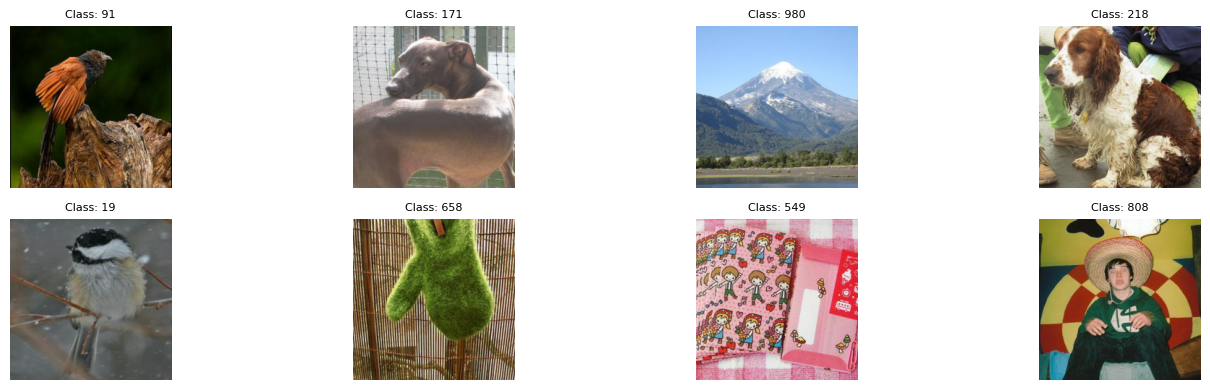


✓ Sample batch shape: torch.Size([64, 3, 224, 224])
  [batch_size, channels, height, width] = [64, 3, 224, 224]
  Label range: 13 to 995


In [6]:
# Function to unnormalize ImageNet images and display
def imshow(img, title=None):
    # Unnormalize using ImageNet mean and std
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)  # Clamp to [0, 1] range

    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title, fontsize=8)
    plt.axis('off')

# Visualize sample images if dataset loaded successfully
if valloader is not None:
    # Get a batch of validation images
    dataiter = iter(valloader)
    images, labels = next(dataiter)

    # Show first 8 images
    plt.figure(figsize=(15, 4))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        imshow(images[i], f"Class: {labels[i].item()}")
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Sample batch shape: {images.shape}")
    print(f"  [batch_size, channels, height, width] = {list(images.shape)}")
    print(f"  Label range: {labels.min().item()} to {labels.max().item()}")
else:
    print("\n⚠ Skipping visualization - dataset not loaded")
    print("Please load ImageNet validation set first (see cell above)")

---

## ✅ Section 1 Complete!

**Environment Check Summary:**
- GPU detected and verified
- All dependencies installed
- Libraries imported
- PyTorch GPU access confirmed
- ImageNet validation set configured (50K images, 1000 classes, 224x224)

**Dataset Info:**
- **ImageNet validation**: 50,000 images across 1,000 classes
- **Resolution**: 224×224 (standard for pre-trained models)
- **Normalization**: ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

**Next Steps:** Ready to implement Section 2 (FFT & Learnable Frequency Mask architecture)

## Section 2: FFT & Learnable Frequency Mask

**Goal:** Implement the core pipeline:
- Input Image → FFT → Learnable Frequency Mask → IFFT → Reconstructed Image

**Frequency Mask Design:**
- Using radial frequency bands (10-100 learnable parameters)
- Each band learns a weight to amplify/suppress frequencies
- More interpretable than full 2D mask

In [8]:
import torch
import torch.nn as nn
import torch.fft

def apply_fft(images):
    """
    Apply 2D FFT to a batch of images.

    Args:
        images: Tensor of shape [B, C, H, W]

    Returns:
        fft_result: Complex tensor of shape [B, C, H, W]
    """
    # Apply FFT to each channel separately
    fft_result = torch.fft.fft2(images, dim=(-2, -1))

    # Shift zero frequency to center
    fft_result = torch.fft.fftshift(fft_result, dim=(-2, -1))

    return fft_result

def apply_ifft(fft_result):
    """
    Apply inverse 2D FFT to reconstruct image.

    Args:
        fft_result: Complex tensor of shape [B, C, H, W]

    Returns:
        reconstructed: Real tensor of shape [B, C, H, W]
    """
    # Shift back from center
    fft_result = torch.fft.ifftshift(fft_result, dim=(-2, -1))

    # Apply inverse FFT
    reconstructed = torch.fft.ifft2(fft_result, dim=(-2, -1))

    # Take real part (imaginary should be ~0)
    reconstructed = reconstructed.real

    return reconstructed

# Test FFT/IFFT pipeline
print("Testing FFT/IFFT pipeline...")

# Create dummy image
test_img = torch.randn(2, 3, 224, 224).to(device)

# Forward FFT
fft_result = apply_fft(test_img)
print(f"✓ FFT output shape: {fft_result.shape}, dtype: {fft_result.dtype}")

# Inverse FFT (should reconstruct original)
reconstructed = apply_ifft(fft_result)
print(f"✓ IFFT output shape: {reconstructed.shape}, dtype: {reconstructed.dtype}")

# Check reconstruction error
reconstruction_error = torch.mean(torch.abs(test_img - reconstructed))
print(f"✓ Reconstruction error: {reconstruction_error.item():.2e} (should be ~1e-6)\n")

if reconstruction_error < 1e-4:
    print("✅ FFT/IFFT pipeline working correctly!")
else:
    print("⚠ Warning: High reconstruction error - check FFT implementation")

Testing FFT/IFFT pipeline...
✓ FFT output shape: torch.Size([2, 3, 224, 224]), dtype: torch.complex64
✓ IFFT output shape: torch.Size([2, 3, 224, 224]), dtype: torch.float32
✓ Reconstruction error: 3.22e-07 (should be ~1e-6)

✅ FFT/IFFT pipeline working correctly!


In [9]:
class RadialFrequencyMask(nn.Module):
    """
    Learnable frequency mask using radial frequency bands.

    Each radial band has a learnable weight to amplify/suppress frequencies.
    This is more interpretable than learning a full 2D mask.
    """

    def __init__(self, image_size=224, num_bands=10, init_value=1.0):
        """
        Args:
            image_size: Size of input images (assumes square)
            num_bands: Number of radial frequency bands (10-100)
            init_value: Initial value for mask weights (1.0 = no change)
        """
        super(RadialFrequencyMask, self).__init__()

        self.image_size = image_size
        self.num_bands = num_bands

        # Learnable weights for each frequency band (these are the ONLY trainable params!)
        self.band_weights = nn.Parameter(torch.ones(num_bands) * init_value)

        # Pre-compute radial frequency map (fixed, not trainable)
        self.register_buffer('radial_map', self._create_radial_map())

        print(f"RadialFrequencyMask initialized:")
        print(f"  Image size: {image_size}x{image_size}")
        print(f"  Number of bands: {num_bands}")
        print(f"  Trainable parameters: {num_bands}")

    def _create_radial_map(self):
        """
        Create a map assigning each frequency pixel to a radial band.

        Returns:
            radial_map: Tensor of shape [H, W] with values in [0, num_bands-1]
        """
        # Create coordinate grids centered at image center
        center = self.image_size // 2
        y, x = torch.meshgrid(
            torch.arange(self.image_size, dtype=torch.float32),
            torch.arange(self.image_size, dtype=torch.float32),
            indexing='ij'
        )

        # Compute distance from center (DC component)
        distances = torch.sqrt((x - center)**2 + (y - center)**2)

        # Normalize distances to [0, 1]
        max_distance = torch.sqrt(torch.tensor(2.0)) * center
        normalized_distances = distances / max_distance

        # Map to band indices [0, num_bands-1]
        band_indices = (normalized_distances * self.num_bands).clamp(0, self.num_bands - 1).long()

        return band_indices

    def forward(self, fft_result):
        """
        Apply learnable frequency mask to FFT result.

        Args:
            fft_result: Complex tensor [B, C, H, W] from FFT

        Returns:
            masked_fft: Complex tensor [B, C, H, W] after masking
        """
        # Create mask from learnable band weights
        # Shape: [H, W] -> values are band_weights[radial_map[i,j]]
        mask = self.band_weights[self.radial_map]  # [H, W]

        # Expand mask to match FFT shape [B, C, H, W]
        mask = mask.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

        # Apply mask (multiply complex FFT by real mask)
        masked_fft = fft_result * mask

        return masked_fft

    def get_mask_visualization(self):
        """Returns the current mask as a 2D numpy array for visualization."""
        mask = self.band_weights[self.radial_map]
        return mask.detach().cpu().numpy()

# Test Radial Frequency Mask
print("\n" + "="*60)
print("Testing RadialFrequencyMask...")
print("="*60 + "\n")

mask_model = RadialFrequencyMask(image_size=224, num_bands=10).to(device)

# Check number of parameters
num_params = sum(p.numel() for p in mask_model.parameters() if p.requires_grad)
print(f"\n✓ Total trainable parameters: {num_params}")

# Test forward pass
test_fft = apply_fft(test_img)
masked_fft = mask_model(test_fft)
reconstructed = apply_ifft(masked_fft)

print(f"✓ Masked FFT shape: {masked_fft.shape}")
print(f"✓ Reconstructed image shape: {reconstructed.shape}")
print(f"\n✅ RadialFrequencyMask working correctly!")


Testing RadialFrequencyMask...

RadialFrequencyMask initialized:
  Image size: 224x224
  Number of bands: 10
  Trainable parameters: 10

✓ Total trainable parameters: 10
✓ Masked FFT shape: torch.Size([2, 3, 224, 224])
✓ Reconstructed image shape: torch.Size([2, 3, 224, 224])

✅ RadialFrequencyMask working correctly!



Visualizing initial frequency mask (before training):


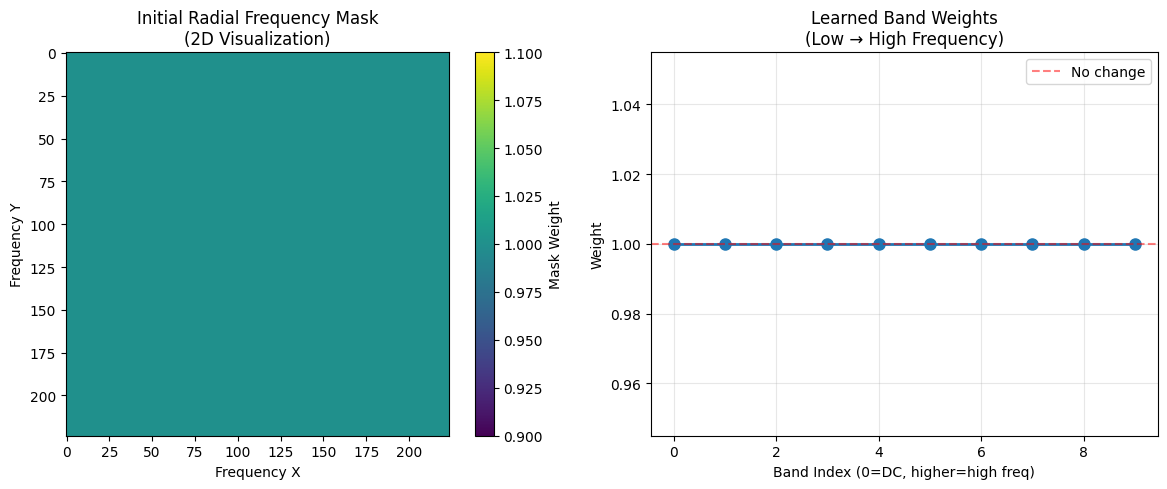


✅ Section 2 Complete!

Ready for Section 3: Load Frozen Classifiers


In [10]:
import matplotlib.pyplot as plt

def visualize_frequency_mask(mask_model, title="Radial Frequency Mask"):
    """
    Visualize the current state of the frequency mask.

    Args:
        mask_model: RadialFrequencyMask instance
        title: Plot title
    """
    mask_vis = mask_model.get_mask_visualization()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 2D mask visualization
    im = axes[0].imshow(mask_vis, cmap='viridis')
    axes[0].set_title(f'{title}\n(2D Visualization)', fontsize=12)
    axes[0].set_xlabel('Frequency X')
    axes[0].set_ylabel('Frequency Y')
    axes[0].axis('on')
    plt.colorbar(im, ax=axes[0], label='Mask Weight')

    # Radial profile (band weights)
    band_weights = mask_model.band_weights.detach().cpu().numpy()
    axes[1].plot(range(len(band_weights)), band_weights, 'o-', linewidth=2, markersize=8)
    axes[1].set_title('Learned Band Weights\n(Low → High Frequency)', fontsize=12)
    axes[1].set_xlabel('Band Index (0=DC, higher=high freq)')
    axes[1].set_ylabel('Weight')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='No change')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Visualize initial mask (all weights = 1.0)
print("\nVisualizing initial frequency mask (before training):")
visualize_frequency_mask(mask_model, title="Initial Radial Frequency Mask")

print("\n✅ Section 2 Complete!")
print("\nReady for Section 3: Load Frozen Classifiers")